# NSU BDA. 2024 Accidents
Соревнование для студенттов курса АБМД, ФИТ НГУ 2024

Студент: Митюшин Владимир 24221

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Загрузим данные

In [16]:
X_train = pd.read_csv('../data/X_train.csv', index_col=0)
X_testFinal = pd.read_csv('../data/X_test.csv', index_col=0)
Y_train = pd.read_csv('../data/Y_train.csv', index_col=0)

Выведем информацию по датасетам

In [17]:
# X_train.info()

In [18]:
# Y_train.info()

Посмотрим более подробно на целевой признак

In [19]:
print("min: ", Y_train['casualty_severity'].min())
print("max: ", Y_train['casualty_severity'].max())
print("unique: ", Y_train['casualty_severity'].unique())

min:  1
max:  3
unique:  [3 2 1]


In [20]:
print(Y_train.value_counts())

casualty_severity
3                    402496
2                     90535
1                      6025
Name: count, dtype: int64


### Исходя из возможных значений целевого признака понимаем, что имеем задачу классификации

## Очистка и подготовка данных

In [21]:
# all = X_train.copy()
# all['y'] = Y_train['casualty_severity']
# class1 = all[all['y'] == 1]
# class2 = all[all['y'] == 2]
# class3 = all[all['y'] == 3]

In [22]:
# class1.describe()

In [23]:
# class1.hist(figsize=(20, 15));

In [24]:
# class2.describe()

In [25]:
# class2.hist(figsize=(20, 15));

In [26]:
# class3.describe()

In [27]:
# from imblearn.over_sampling import SMOTE
# from sklearn.preprocessing import OneHotEncoder
# from imblearn.pipeline import Pipeline

# steps = [('onehot', OneHotEncoder()), ('smt', SMOTE())]
# pipeline = Pipeline(steps=steps)

# x = X_train.copy()
# x['generic_make_model'] = x['generic_make_model'].str.split(n=1).str[0].str.upper()
# x['local_authority_highway'] = x['local_authority_highway'].str[:4]

# df, y = pipeline.fit_resample(x, Y_train)

In [28]:
df = X_train.copy()

In [29]:
# df.hist(figsize=(20, 15));

In [30]:
# df[df.select_dtypes('number').columns].corr().style.background_gradient(cmap='coolwarm')

In [31]:
drop_indexes = df.index[df['age_of_vehicle'] > 25].tolist() # drop_indexes = 
df.drop(drop_indexes, inplace=True)
Y_train.drop(drop_indexes, inplace=True)

# df['sex_of_casualty'] = df['sex_of_casualty'].replace(9, -1).replace(-1, df['sex_of_casualty'].median())
# df['car_passenger'] = df['car_passenger'].replace(9, -1)
# df['casualty_type'] = df['casualty_type'].replace([3, 4, 5, 22, 23, 97, 103, 104, 105, 106], 2).replace([20, 21, 98, 113], 19)

df.describe()

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,...,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,...,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000
mean,1.457198,1.473239,1.367787,36.783498,6.307857,0.760861,0.615109,0.232495,0.050626,0.026024,...,37.519117,3.786146,1.679830,2.996640,223.640848,0.323232,1.107123,2.057349,1.639340,1.372062
std,2.328807,0.725779,0.530250,19.515151,2.453357,2.147320,1.965782,0.628303,0.437022,0.232720,...,14.734068,12.024490,2.516754,2.757978,936.349753,1.640876,2.375471,1.735270,1.791897,0.931780
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,30.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,30.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,50.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,50.000000,3.000000,4.000000,6.000000,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000
max,999.000000,3.000000,9.000000,102.000000,11.000000,10.000000,9.000000,9.000000,9.000000,2.000000,...,70.000000,99.000000,9.000000,6.000000,9999.000000,9.000000,9.000000,7.000000,9.000000,9.000000


In [32]:
df = df.drop(columns=['accident_index', 'vehicle_reference'])

In [33]:
df = df.drop(columns='age_of_casualty')
# df = df.drop(columns='age_band_of_casualty')
df = df.drop(columns='car_passenger')
df = df.drop(columns='pedestrian_location')
# df = df.drop(columns='pedestrian_movement')
df = df.drop(columns='second_road_number')
df = df.drop(columns='first_road_number')
# df = df.drop(columns='junction_control')
df = df.drop(columns='pedestrian_crossing_human_control')
df = df.drop(columns='pedestrian_crossing_physical_facilities')
df = df.drop(columns='engine_capacity_cc')
df = df.drop(columns='casualty_type')
df = df.drop(columns='bus_or_coach_passenger')
df = df.drop(columns='pedestrian_road_maintenance_worker')
df = df.drop(columns='vehicle_left_hand_drive') 
# df = df.drop(columns='vehicle_manoeuvre') 
# df = df.drop(columns='junction_detail') 
# df = df.drop(columns='vehicle_type')
df = df.drop(columns='casualty_home_area_type')
df = df.drop(columns='casualty_distance_banding')

In [34]:
# drop_indexes = []
# for i, row in df.select_dtypes('number').iterrows():
#     tmp = row.isin([-1, 0])
#     for e in tmp:
#         if e:
#             drop_indexes.append(i)
#             continue

# df.drop(drop_indexes, inplace=True)
# Y_train.drop(drop_indexes, inplace=True)

In [35]:
df.describe()

,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_movement,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions
count,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000
mean,1.473239,1.367787,6.307857,0.615109,9.259128,19.414857,6.038956,28.313888,4.144238,5.232448,37.519117,3.786146,1.679830,2.996640,2.057349,1.639340,1.372062
std,0.725779,0.530250,2.453357,1.965782,11.371588,21.912934,6.155468,24.407225,1.470678,1.673324,14.734068,12.024490,2.516754,2.757978,1.735270,1.791897,0.931780
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,1.000000,5.000000,0.000000,8.000000,9.000000,0.000000,5.000000,3.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,6.000000,0.000000,9.000000,18.000000,5.000000,23.000000,4.000000,6.000000,30.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,8.000000,0.000000,9.000000,18.000000,11.000000,45.000000,6.000000,6.000000,50.000000,3.000000,4.000000,6.000000,4.000000,1.000000,2.000000
max,3.000000,9.000000,11.000000,9.000000,99.000000,99.000000,25.000000,99.000000,6.000000,9.000000,70.000000,99.000000,9.000000,6.000000,7.000000,9.000000,9.000000


In [36]:
# import holoviews as hv
# from holoviews import dim
# from holoviews import opts
# hv.extension('bokeh')

# def f(x):
#     return hv.BoxWhisker(df[x]).opts(height=120, responsive=True, toolbar='above', invert_axes=True, tools=['hover'])

# hv.DynamicMap(f, kdims=['x']).redim.values(x=df.select_dtypes('number').columns)

In [37]:
# df.hist(figsize=(20, 11));

### Посмотрим на категориальные признаки

In [38]:
# df.describe(include='O')

In [39]:
df['generic_make_model'] = df['generic_make_model'].str.split(n=1).str[0].str.upper()
display(df['generic_make_model'].value_counts(dropna=False))

generic_make_model
-1            131368
FORD           43961
VAUXHALL       36308
VOLKSWAGEN     28300
HONDA          25695
               ...  
CASE               7
OPEL               6
PROTON             6
VALTRA             5
VESPA              4
Name: count, Length: 114, dtype: int64

In [40]:
# display(df['local_authority_highway'].value_counts(dropna=False))

In [41]:
df['local_authority_highway'] = df['local_authority_highway'].str[:4]
display(df['local_authority_highway'].value_counts(dropna=False))

local_authority_highway
E100    158523
E060    115079
E090    100761
E080     83500
S120     21799
W060     16905
EHEA        98
Name: count, dtype: int64

In [42]:
# df.drop(columns=['local_authority_highway', 'generic_make_model'], inplace=True)

In [43]:
one_hot = pd.get_dummies(df.select_dtypes('O'), prefix=df.select_dtypes('O').columns, dtype=bool)
df = pd.concat([one_hot, df.select_dtypes('number'), df.select_dtypes('bool')], axis=1)

df.describe()

,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_movement,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions
count,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000,496665.000000
mean,1.473239,1.367787,6.307857,0.615109,9.259128,19.414857,6.038956,28.313888,4.144238,5.232448,37.519117,3.786146,1.679830,2.996640,2.057349,1.639340,1.372062
std,0.725779,0.530250,2.453357,1.965782,11.371588,21.912934,6.155468,24.407225,1.470678,1.673324,14.734068,12.024490,2.516754,2.757978,1.735270,1.791897,0.931780
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,1.000000,5.000000,0.000000,8.000000,9.000000,0.000000,5.000000,3.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,6.000000,0.000000,9.000000,18.000000,5.000000,23.000000,4.000000,6.000000,30.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,8.000000,0.000000,9.000000,18.000000,11.000000,45.000000,6.000000,6.000000,50.000000,3.000000,4.000000,6.000000,4.000000,1.000000,2.000000
max,3.000000,9.000000,11.000000,9.000000,99.000000,99.000000,25.000000,99.000000,6.000000,9.000000,70.000000,99.000000,9.000000,6.000000,7.000000,9.000000,9.000000


In [44]:
# df.info()

## Перейдём к обучению

In [45]:
Y_train = Y_train.apply(lambda y: y-1)
# y = y.apply(lambda y: y-1)

X_train, X_test, y_train, y_test = train_test_split(df, Y_train, random_state=42) # Y_train
print(X_train.shape, y_train.shape)

(372498, 138) (372498, 1)


In [46]:
# # ADASYN
# from imblearn.over_sampling import ADASYN
# adasyn = ADASYN()
# # df_resampled, y_resampled = adasyn.fit_resample(df, Y_train)
# X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

In [47]:
# from imblearn.over_sampling import SMOTE
# smote = SMOTE()

# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [48]:
# from imblearn.under_sampling import RandomUnderSampler
# rus = RandomUnderSampler()

# X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [49]:
# from imblearn.over_sampling import RandomOverSampler
# ros = RandomOverSampler()

# X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

In [50]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
from sklearn.utils.class_weight import compute_sample_weight

# class_weights = compute_sample_weight('balanced', y=y_train_resampled.values.ravel())
class_weights = compute_sample_weight('balanced', y=y_train.values.ravel())
print(np.unique(class_weights))
for i in range(0, class_weights.size):
    tmp = class_weights[i]
    if int(tmp)==27:
        class_weights[i] = 5.0
    elif int(tmp) == 1:
        class_weights[i] = 0.9
    else: class_weights[i] = 0.3
print(np.unique(class_weights))

[ 0.41305917  1.84135129 27.8087346 ]
[0.3 0.9 5. ]


In [63]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 1, 3, 5, 7, 10],
    # 'min_samples_leaf': [1, 2, 4]
}
# model = XGBClassifier()
# random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=20, cv=5)
# random_search.fit(X_train, y_train)

model = XGBClassifier(n_estimators = 76, max_depth=5, objective='multi: softmax', num_class=3, random_state=42, base_score=0.2)
model.fit(X_train, y_train.values.ravel(), sample_weight=class_weights)
# model.fit(X_train_resampled, y_train_resampled.values.ravel(), sample_weight=class_weights)

# print("Best Hyperparameters:", random_search.best_params_)
# print("Best Cross-Validation Score:", random_search.best_score_)

XGBClassifier(base_score=0.2, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=76, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [64]:
# y_pred_train = model.predict(X_train_resampled)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [65]:
# f1_train = f1_score(y_train_resampled, y_pred_train, average='macro')
f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test = f1_score(y_test, y_pred_test, average='macro')
print(f1_train, f1_test)

0.48299793555980713 0.459249720482537


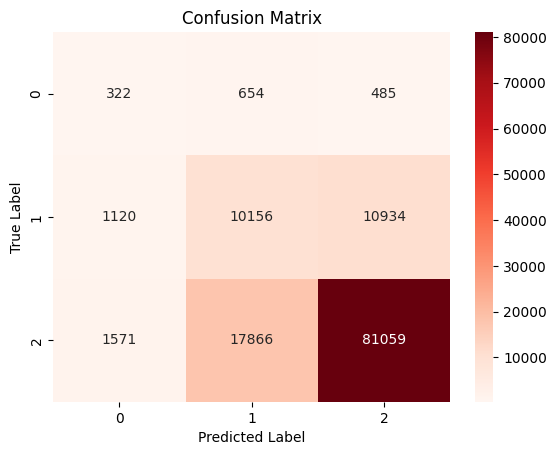

In [47]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred_test)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [40]:
X_testFinal = pd.read_csv('../data/X_test.csv', index_col=0)

X_testFinal = X_testFinal.drop(columns=['accident_index', 'vehicle_reference'])
X_testFinal = X_testFinal.drop(columns=['age_of_casualty', 'pedestrian_movement', 'pedestrian_crossing_human_control', 'pedestrian_crossing_physical_facilities', 'engine_capacity_cc'])
X_testFinal['generic_make_model'] = X_testFinal['generic_make_model'].str.split(n=1).str[0].str.upper()
X_testFinal['local_authority_highway'] = X_testFinal['local_authority_highway'].str[:4]

one_hot = pd.get_dummies(X_testFinal.select_dtypes('O'), prefix=X_testFinal.select_dtypes('O').columns, dtype=bool)
X_testFinal = pd.concat([one_hot, X_testFinal.select_dtypes('number'), X_testFinal.select_dtypes('bool')], axis=1)

X_testFinal = X_testFinal.reindex(df.columns, axis=1, fill_value=0)
X_testFinal.describe()

,generic_make_model_DERBI,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_movement,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions
count,166352.0,166352.000000,166352.000000,166352.000000,166352.0,166352.000000,166352.000000,166352.00000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000
mean,0.0,1.470322,1.366873,6.305587,0.0,9.234791,19.306639,6.18414,28.323892,4.149598,5.238975,37.547730,3.767667,1.687151,3.008446,2.051848,1.634257,1.371369
std,0.0,0.722688,0.532466,2.455111,0.0,11.294774,21.728723,6.47909,24.336775,1.469986,1.665436,14.710353,11.917428,2.512841,2.759564,1.732798,1.787258,0.933177
min,0.0,1.000000,-1.000000,-1.000000,0.0,-1.000000,-1.000000,-1.00000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.0,1.000000,1.000000,5.000000,0.0,8.000000,9.000000,0.00000,5.000000,3.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000
50%,0.0,1.000000,1.000000,6.000000,0.0,9.000000,18.000000,5.00000,23.000000,4.000000,6.000000,30.000000,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000
75%,0.0,2.000000,2.000000,8.000000,0.0,9.000000,18.000000,11.00000,45.000000,6.000000,6.000000,50.000000,3.000000,4.000000,6.000000,4.000000,1.000000,2.000000
max,0.0,3.000000,9.000000,11.000000,0.0,99.000000,99.000000,97.00000,99.000000,6.000000,9.000000,70.000000,99.000000,9.000000,6.000000,7.000000,9.000000,9.000000


In [41]:
y_predicted_Final = model.predict(X_testFinal)
y_predicted_Final = y_predicted_Final +1

print(y_predicted_Final)

[3 3 3 ... 3 3 3]


In [48]:
# my_file = open("../predicts/rf_balance4_0.46.csv", "w+")

# my_file.write("Id,casualty_severity\n")
# my_i = 0
# for i, row in X_testFinal.iterrows():
#     my_file.write(f"{i}, {y_predicted_Final[my_i]}\n")
#     my_i = my_i+1
# my_file.close()